# Data Fitting
One of the most common data analysis problems and, one you will frequently encounter in a physics laboratory is fitting a curve to a set of data points. Suppose you have a set of $N$ data points $\{x_i, y_i\}$ and that you wish to fit the data to the function $$y(x) = a x + b,$$ where the $a$ and $b$ are adjustable parameters that give the "best fit." This page just describes the programming that needs to be done to find the best fit parameters $a$ and $b$ and their associated uncertainties. We will use data from an experiment to measure Planck's constant to illustrate the process. You can read more about what constitues the "best fit" on the <a href="https://faculty1.coloradocollege.edu/~sburns/toolbox/DataFitting.html">Scientific Computing Toolbox website</a> or refer to one of the books [referenced below](#references). 

## Finding Planck's Constant
In 1921, Einstein was give the Nobel Prize "for his services to Theoretical Physics, and especially for his discovery of the law of the photoelectric effect." His law predicts that when light of frequency $f$ shines on a metal electrons will be ejected from the metal with a maximum kinetic energy $$K_{max} = h f - \phi,$$ where $h$ is Planck's constant and $\phi$ is the <i>work function</i> of the metal. If we can measure the maximum kinetic energy of the electrons for light of several frequencies we should be able to determine Planck's constant and the work function by doing a linear fit. The slope of the line will give Planck's constant and the intercept will give the work function.

### Fitting without uncertainties
The table below shows some data for a photoelectric effect experiment. There are no uncertanty estimates for the data. There is always some uncertainty in any measurement, but sometimes it's difficult to estimate. That's the case with these data.  

  $f$ (Hz)  | $K_{max}$ (J)
 ---        | ---  
 8.213&times;10<sup>14</sup> | 3.107&times;10<sup>-19</sup>
 7.402&times;10<sup>14</sup> | 2.551&times;10<sup>-19</sup>
 6.876&times;10<sup>14</sup> |2.200&times;10<sup>-19</sup>
 5.491&times;10<sup>14</sup> |1.306&times;10<sup>-19</sup>
 5.196&times;10<sup>14</sup> |1.110&times;10<sup>-19</sup>
 
Before we can fit the data, we must put it in a computer readable text file. You can use the Atom text editor to create the file. The file must consist of two columns separated by spaces as shown below.
```
8.213e+14	3.107e-19
7.402e+14	2.551e-19
6.876e+14	2.200e-19
5.491e+14	1.306e-19
5.196e+14	1.110e-19
```
Copy the text above into a file using the Atom text editor, and save it in a file named
`data_noerror.txt`. Once you have this file you will be ready to go through the steps needed to do a linear fit. Start by begining an IPython session so you can follow along. Don't forget to use `cd` to go to the directory containing the `data_noerror.txt` file before you start IPython. (If you like you can [download the fitting.zip file](fitting.zip). It contains the data files, the fitting programs, and this page's [Jupyter Notebook](http://jupyter.org).)

The first step is to import the needed Python modules.

In [1]:
from pylab import *
from scipy.optimize import curve_fit

The first is the familar command for importing the entire `pylab` module. The second line imports a single function `curve_fit()` from the `scipy.optimize` module. 

Next we read the data from the `data_noerror.txt` file.

In [2]:
freq,Kmax=loadtxt('data_noerror.txt',unpack=True)

This command reads the data from the file `data_noerror.txt` and loads the first column in the file into the `freq` array and the second column into `Kmax`. The `unpack=True` argument is needed to load the columns properly. (See the [SciPy documentation](https://docs.scipy.org/doc/numpy/reference/generated/numpy.loadtxt.html) if you want to understand exactly what `unpack=True` argument does.) 

Now we need to define the function we wish to fit. The `curvefit()` function will actually fit any arbitrary function. When we run `curve_fit()` we must pass it the name of a fitting function that we must write. In this case we want to fit our data to a straight line. In Python we define functions with the `def` command followed by the name of the function and then the function's arguments. All *indented* lines after the definition line are included in the function. An example will make this clearer. 

In [3]:
def linearFunc(x,intercept,slope):
    y = intercept + slope * x
    return y

The `return y` statement tells Python to return the value of `y` whenever the function is called. For example: 

In [4]:
linearFunc(1,2,3)

5

You can give your function any name you like. I called it `linearFunc` here.

The next step is to actually do the fit using `curvefit()`. We must pass the name of the function to fit and the horizontal axis data and the vertical axis data. The program returns some arrays containing the best fit parameters and the [covariance matrix](https://en.wikipedia.org/wiki/Covariance_matrix). We will use the covariance matrix to determine the uncertainites in the slope and intercept of the best fit line.

In [5]:
a_fit,cov=curve_fit(linearFunc,freq,Kmax)

The next two lines assign the best-fit parameters returned by the `curve_fit()` to the variable `inter` and `slope`. 

In [6]:
inter = a_fit[0]
slope = a_fit[1]

Next, the uncertainties in the intercept and slope are computed from the covarience matrix and assigned to the variables `d_inter` and `d_slope`.

In [7]:
d_inter = sqrt(cov[0][0])
d_slope = sqrt(cov[1][1])

The following code is used to plot the data and the fit.

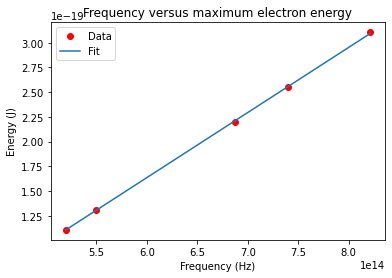

In [8]:
# Create a graph showing the data.
plot(freq,Kmax,'ro',label='Data')

# Compute a best fit from the fit intercept and slope.
Kmax_fit = inter + slope*freq

# Create a graph of the fit to the data.
plot(freq,Kmax_fit,label='Fit')

# Display a legend, label the x and y axes and title the graph.
legend()
xlabel('Frequency (Hz)')
ylabel('Energy (J)')
title('Frequency versus maximum electron energy')

# Save the figure to a file
savefig('noerror_fit.png')

# Show the graph in a new window on the users screen.
show()

We will use a the `print()` command to print the best fit parameters and uncertainties. Here we use [Python f-strings](https://realpython.com/python-f-strings/) to present the result. F-strings are prefixed with an `f`  and allow us to include variable names enclosed in `{}`. When the string is printed the values for the variables are substituted into the string. Again, an example makes this clearer.  

In [9]:
# Display the best fit values for the slope and intercept. These print
# statments illustrate how to print a mix of strings and variables.
print(f'The slope = {slope}, with uncertainty {d_slope}')
print(f'The intercept = {inter}, with uncertainty {d_inter}')

The slope = 6.58375394121593e-34, with uncertainty 4.8389301124256446e-36
The intercept = -2.314103516495066e-19, with uncertainty 3.2581297976065846e-21


By default, f-strings usually present the results with more precision than we need, but it's easy to round the numbers to the desired precision. You can learn more about controling the display precision on the [Python Documentation website.](https://docs.python.org/3/reference/lexical_analysis.html#formatted-string-literals) 

This example gives a good result for Planck's constant. It agrees well with the accpeted value.

### Fitting *with* uncertainties
Suppose we had data with estimated uncertainties in $K_{max}$ and wished to take these uncertainties into account in our fit. A table of the data is shown below. A text file with this data called `data_error.txt` is included in the [fitting.zip file](fitting.zip).

$f$ (Hz)     |   $K_{max}$ (J)   |   $\delta_{Kmax}$ (J)
--- | --- | ---
8.213&times;10<sup>14</sup>   |   3.261&times;10<sup>-19</sup>   |   9.71&times;10<sup>-21</sup>
7.402&times;10<sup>14</sup>   |   2.52&times;10<sup>-19</sup>    |  5.59&times;10<sup>-21</sup>
6.876&times;10<sup>14</sup>   |   2.239&times;10<sup>-19</sup>   |   7.08&times;10<sup>-21</sup>
5.491&times;10<sup>14</sup>   |   1.299&times;10<sup>-19</sup>   |   6.83&times;10<sup>-21</sup>
5.196&times;10<sup>14</sup>   |   1.175&times;10<sup>-19</sup>   |   8.93&times;10<sup>-21</sup>

The code is almost identical, but this time we must read the uncertainties from the file, and pass an array containing these uncertainties to `curvefit()`. 

It's simple to read the the uncertainties into an array. We just include a variable called `d_Kmax` on the line calling the `loadtxt()` function. After the call, the array called `d_Kmax` contains the uncertainties.

In [10]:
freq,Kmax,d_Kmax=loadtxt('data_error.txt',unpack=True)

We pass the uncertainties to `curve_fit` by adding the argument `sigma=d_Kmax` to the function call.

In [11]:
a_fit,cov=curve_fit(linearFunc,freq,Kmax,sigma=d_Kmax)

We get the best fit slope and the uncertainties from `a_fit` and `cov` the same way we did before.

In [12]:
inter = a_fit[0]
slope = a_fit[1]
d_inter = sqrt(cov[0][0])
d_slope = sqrt(cov[1][1])

We use the function `errorbar()` to plot the data showing error bars on the data points. It works very much like the `plot()` command. We just have to specify the array containing the uncertainties with an extra argument `yerr=d_Kmax`. The `errorbar()` function also requires that we specify the format to be used to display the data points. In this case the argument `fmt='r.'` will display the data as red dots.

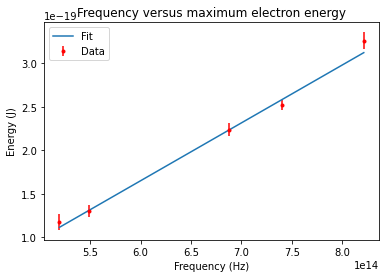

In [13]:
# Create a graph showing the data.
errorbar(freq,Kmax,yerr=d_Kmax,fmt='r.',label='Data')

# Compute a best fit line from the fit intercept and slope.
Kmax_fit = inter + slope*freq

# Create a graph of the fit to the data. We just use the ordinary plot
# command for this.
plot(freq,Kmax_fit,label='Fit')

# Display a legend, label the x and y axes and title the graph.
legend()
xlabel('Frequency (Hz)')
ylabel('Energy (J)')
title('Frequency versus maximum electron energy')

# Save the figure to a file
savefig('error_fit.png')

# Show the graph in a new window on the users screen.
show()

Now we can display the numerical result.

In [14]:
print(f'The slope = {slope}, with uncertainty {d_slope}')
print(f'The intercept = {inter}, with uncertainty {d_inter}')

The slope = 6.6560286973775526e-34, with uncertainty 3.549213552024548e-35
The intercept = -2.343068168255266e-19, with uncertainty 2.395324805774619e-20


When we have estimated uncertainties in the data, then we can estimate the goodness of fit by computing the reduced chi-squared statistic. For a linear fit to a set of $N$ data points $\{x_i,y_i\}$ that have esimated uncertainties in the $y_i$ values of $\{\sigma_i\}$,  
$$
\chi_r^2 = \frac{1}{N-2}\sum_{i=1}^N \frac{\left(y_i-y(x_i)\right)^2}{\sigma_i},
$$
where for a linear fit $y(x) = a + bx$.  For a good fit, $\chi_r^2$ should be approximatly equal to one.

In [15]:
chisqr = sum((Kmax-linearFunc(freq,inter,slope))**2/d_Kmax**2)
dof = len(Kmax) - 2
chisqr_red = chisqr/dof
print(f'Reduced chi^2 = {chisqr_red}')

Reduced chi^2 = 1.2633310164062912


In this case, the computed value of $\chi_r^2$ is close to one indicating a good fit. See the [Scientific Computing Toobox: Data Fitting](https://faculty1.coloradocollege.edu/~sburns/toolbox/DataFitting.html) page or the [references listed at the end of this page](#references) for a more complete discussion of the reduced chi-square statistic. 

## Summary

The code above is all you should need to do linear fits to data. When you're confronted with a new data analysis problem that requires a fit, it is usually faster to modify existing code than to reinvent it every time. I've included two Python scripts, two data files, and the Jupyter Notebook that generated this page in a ZIP file. ([Download the fitting.zip file](fitting.zip)) Feel free to modify the programs and use them when you need to do a linear fit.

A table with a short description of the Python functions used in this tutorial is posted on the [Scientific Computing Toolbox: Command Summary Page](https://faculty1.coloradocollege.edu/%7Esburns/toolbox/CommandSummary.html). 


<hr>
<a name="references"><b>References</b></a>

1. Bevington and Robinson, *Data Reduction and Error Analysis for the Physical Sciences 3rd Edition* (McGraw-Hill Education, 2002)  
2. Taylor, *An Introduction to Error Analysis: The Study of Uncertainties in Physical Measurements 2nd Edition*, (University Science Books, 1996)